In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
PROJECT_PATH = "/content/drive/MyDrive/Telco-customer-churn"

In [39]:
import pandas as pd
import sqlite3
import numpy as np

In [40]:
df = pd.read_csv(
    f"{PROJECT_PATH}/Data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [41]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [43]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [44]:
df['Churn_Flag'] = df['Churn'].map({'Yes': 1, 'No': 0})
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Flag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [45]:
df['Revenue_at_risk'] = df.apply(lambda x: x['MonthlyCharges'] if x['Churn_Flag'] == 1 else 0, axis = 1)

In [46]:
df.to_csv(f'{PROJECT_PATH}/Data/WA_Fn-UseC_-Telco-Customer-Churn-Processed.csv', index=False)

In [47]:
# Load into SQLite so we can write real SQL queries
import sqlite3

conn = sqlite3.connect('../content/telco_churn.db')
df.to_sql('customers', conn, if_exists='replace', index=False)

print(f"Rows loaded: {pd.read_sql('SELECT COUNT(*) as n FROM customers', conn).iloc[0,0]}")
print(f"Churned customers: {df['Churn_Flag'].sum()}")
print(f"Total monthly revenue at risk: ₹{df['Revenue_at_risk'].sum():,.0f}")

Rows loaded: 7032
Churned customers: 1869
Total monthly revenue at risk: ₹139,131


In [48]:
def run_query(label, query):
  print(f"\n{'='*100}")
  print(f" {label}")
  print('='*100)
  result=pd.read_sql(query, conn)
  print(result.to_string(index=False))
  print('='*100)
  return result

In [49]:
#Headline Churn rate
q1=run_query("Overall Churn Rate", """
  select count(*) as total_customers,
  sum(Churn_Flag) as churned,
  round(100.0*sum(Churn_Flag)/count(*),1) as churn_rate_pct,
  round(sum(Revenue_at_risk),0) as monthly_rev_at_risk
  from customers
""")


 Overall Churn Rate
 total_customers  churned  churn_rate_pct  monthly_rev_at_risk
            7032     1869            26.6             139131.0


### 💡 Insight: Overall churn is putting significant recurring revenue at risk

**What the data shows:** Out of 7032 customers, 1869 have churned, resulting in an overall churn rate of 26.6%. This represents approximately $139131 in monthly recurring revenue at risk.

**Why it matters:** More than one in four customers leave the business, creating a substantial recurring revenue loss that directly impacts long-term growth and customer lifetime value.

**Action:** Make churn reduction a company-wide KPI by prioritizing high-risk customer segments and tracking monthly revenue at risk alongside churn.


In [50]:
q2=run_query("Churn by Contract Type", """
  select Contract, count(*) as total_customers,
  sum(Churn_Flag) as churned,
  round(100.0*sum(Churn_Flag)/count(*),1) as churn_rate_pct,
  round(sum(Revenue_at_risk),0) as monthly_rev_at_risk
  from customers
  group by Contract
  order by churn_rate_pct desc
""")


 Churn by Contract Type
      Contract  total_customers  churned  churn_rate_pct  monthly_rev_at_risk
Month-to-month             3875     1655            42.7             120847.0
      One year             1472      166            11.3              14118.0
      Two year             1685       48             2.8               4165.0


### 💡 Insight: Contract Type drives churn more than any other factor

**What the data shows:** Month-to-month customers churn at 43% vs 11% on
one-year and 3% on two-year contracts.

**Why it matters:** The majority of the customer base is on month-to-month —
meaning the company's revenue base is structurally fragile.

**Action:** Priority retention spend should target month-to-month customers
in their first 12 months with contract upgrade incentives.


In [51]:
q3=run_query("Churn Rate by Tenure Segment", """
  select case when tenure <= 12 then '1-12 months'
              when tenure <= 24 then '13-24 months'
              when tenure <= 48 then '25-48 months'
              else '48+ months' end as tenure_segment,
  count(*) as total_customers,
  sum(Churn_Flag) as churned,
  round(100.0*sum(Churn_Flag)/count(*),1) as churn_rate_pct,
  round(avg(MonthlyCharges),0) as avg_monthly_charges
  from customers
  group by tenure_segment
  order by churn_rate_pct desc
""")


 Churn Rate by Tenure Segment
tenure_segment  total_customers  churned  churn_rate_pct  avg_monthly_charges
   1-12 months             2175     1037            47.7                 56.0
  13-24 months             1024      294            28.7                 61.0
  25-48 months             1594      325            20.4                 66.0
    48+ months             2239      213             9.5                 74.0


### 💡 Insight: Most customers who churn do so within their first year

**What the data shows:** Customers with 1–12 months tenure have the highest churn rate at 47.7%, which steadily declines to 9.5% for customers staying longer than 48 months.

**Why it matters:** Customer loyalty strengthens over time, making the first year the most critical period for retention. Preventing early churn can significantly improve customer lifetime value.

**Action:** Strengthen onboarding and customer engagement during the first 12 months through proactive support, personalized offers, and early retention campaigns.

In [52]:
q4=run_query("Revenue Profile: Churned vs Retained", """
  select Churn,
  count(*) as total_customers,
  round(avg(MonthlyCharges),0) as avg_monthly_charges,
  round(avg(TotalCharges),0) as avg_total_charges,
  round(sum(MonthlyCharges),0) as total_monthly_revenue
  from customers
  group by Churn
""")


 Revenue Profile: Churned vs Retained
Churn  total_customers  avg_monthly_charges  avg_total_charges  total_monthly_revenue
   No             5163                 61.0             2555.0               316530.0
  Yes             1869                 74.0             1532.0               139131.0


### 💡 Insight: Churned customers generate higher monthly revenue than retained customers

**What the data shows:** Churned customers pay an average of $74/month, compared to $61/month for retained customers, despite having lower average lifetime spending due to shorter tenure.

**Why it matters:** The company is disproportionately losing higher-value customers, increasing the financial impact of churn beyond customer count alone.

**Action:** Identify high-paying customers showing early churn signals and prioritize them with loyalty rewards, service improvements, or personalized retention offers.

In [53]:
q5 = run_query("Churn by Internet Service", """
SELECT
    InternetService,
    COUNT(*)                                          AS total,
    SUM(Churn_Flag)                                   AS churned,
    ROUND(100.0 * SUM(Churn_Flag) / COUNT(*), 1)     AS churn_rate_pct,
    ROUND(SUM(Revenue_At_Risk), 0)                    AS monthly_rev_at_risk
FROM customers
GROUP BY InternetService
ORDER BY churn_rate_pct DESC
""")


 Churn by Internet Service
InternetService  total  churned  churn_rate_pct  monthly_rev_at_risk
    Fiber optic   3096     1297            41.9             114300.0
            DSL   2416      459            19.0              22529.0
             No   1520      113             7.4               2302.0


### 💡 Insight: Fiber optic customers contribute the majority of churn-related revenue loss

**What the data shows:** Fiber optic customers churn at 41.9%, more than double DSL customers (19%) and nearly six times customers without internet (7.4%). This segment alone accounts for $114,300 in monthly revenue at risk.

**Why it matters:** Although Fiber optic customers are high-value, they are also the most likely to leave, making them the biggest contributor to revenue leakage.

**Action:** Investigate Fiber optic customer pain points such as pricing, service quality, or competition, and prioritize targeted retention initiatives for this segment.

In [54]:
q6 = run_query("Top High-Risk Segments", """
SELECT
    Contract,
    InternetService,
    PaymentMethod,
    COUNT(*)                                          AS total,
    SUM(Churn_Flag)                                   AS churned,
    ROUND(100.0 * SUM(Churn_Flag) / COUNT(*), 1)     AS churn_rate_pct,
    ROUND(AVG(MonthlyCharges), 0)                     AS avg_monthly_rev,
    ROUND(SUM(Revenue_At_Risk), 0)                    AS segment_rev_at_risk
FROM customers
GROUP BY Contract, InternetService, PaymentMethod
HAVING total > 30
ORDER BY churn_rate_pct DESC
LIMIT 10
""")


 Top High-Risk Segments
      Contract InternetService             PaymentMethod  total  churned  churn_rate_pct  avg_monthly_rev  segment_rev_at_risk
Month-to-month     Fiber optic          Electronic check   1307      789            60.4             87.0              68282.0
Month-to-month     Fiber optic              Mailed check    201      102            50.7             83.0               8407.0
Month-to-month     Fiber optic Bank transfer (automatic)    327      149            45.6             88.0              13062.0
Month-to-month     Fiber optic   Credit card (automatic)    293      122            41.6             88.0              10731.0
Month-to-month             DSL          Electronic check    474      192            40.5             49.0               8776.0
Month-to-month             DSL              Mailed check    367      113            30.8             49.0               5292.0
Month-to-month             DSL   Credit card (automatic)    185       50            27

### 💡 Insight: Month-to-month Fiber optic customers paying by Electronic Check are the highest-risk segment

**What the data shows:** Customers with Month-to-month contracts, Fiber optic service, and Electronic Check payments have a 60.4% churn rate—the highest among all customer segments—and account for $68,282 in monthly revenue at risk.

**Why it matters:** A relatively small customer segment contributes a disproportionately large share of churn-related revenue loss, making it the most valuable retention opportunity.

**Action:** Prioritize this segment with targeted offers such as automatic payment enrollment, contract upgrade discounts, and proactive customer outreach to reduce churn.

In [55]:
q7 = run_query("Monthly Revenue at Risk", """
SELECT
    ROUND(SUM(MonthlyCharges), 0)                              AS total_mrr,
    ROUND(SUM(Revenue_At_Risk), 0)                             AS revenue_at_risk,
    ROUND(100.0 * SUM(Revenue_At_Risk) / SUM(MonthlyCharges), 1) AS pct_mrr_at_risk
FROM customers
""")


 Monthly Revenue at Risk
 total_mrr  revenue_at_risk  pct_mrr_at_risk
  455661.0         139131.0             30.5


### 💡 Insight: Nearly one-third of monthly recurring revenue is at risk

**What the data shows:** The business generates $455,661 in monthly recurring revenue (MRR), of which $139,131—or 30.5%—comes from customers who eventually churn.

**Why it matters:** Losing nearly one-third of recurring revenue significantly impacts predictable cash flow, profitability, and long-term business growth. Even modest improvements in retention could recover substantial recurring revenue.

**Action:** Track Revenue at Risk as a core business KPI and prioritize retention efforts for high-value, high-risk customer segments to protect recurring revenue.

In [56]:
q8 = run_query("Retention Rate by Tenure Cohort", """
SELECT
    CASE
        WHEN tenure <= 6  THEN '0–6 months'
        WHEN tenure <= 12 THEN '7–12 months'
        WHEN tenure <= 24 THEN '13–24 months'
        WHEN tenure <= 36 THEN '25–36 months'
        ELSE '36+ months'
    END                                               AS cohort,
    COUNT(*)                                          AS total,
    SUM(Churn_Flag)                                   AS churned,
    ROUND(100.0 * (COUNT(*) - SUM(Churn_Flag)) / COUNT(*), 1) AS retention_rate_pct,
    ROUND(AVG(MonthlyCharges), 0)                     AS avg_monthly_rev
FROM customers
GROUP BY cohort
ORDER BY MIN(tenure)
""")


 Retention Rate by Tenure Cohort
      cohort  total  churned  retention_rate_pct  avg_monthly_rev
  0–6 months   1470      784                46.7             55.0
 7–12 months    705      253                64.1             59.0
13–24 months   1024      294                71.3             61.0
25–36 months    832      180                78.4             66.0
  36+ months   3001      358                88.1             72.0


In [57]:
early_churned = 784
recovery_pct = 0.10
avg_rev = 55
print(f"10% retention improvement in 0–6 cohort = ₹{early_churned * recovery_pct * avg_rev:,.0f}/month recovered")

10% retention improvement in 0–6 cohort = ₹4,312/month recovered


## 💡 Insight: The retention cliff is months 0–6, not 0–12

**What the data shows:** Customers in months 0–6 retain at only 46.7%.
Those who reach month 7 retain at 64.1% — a 17-point jump in 6 months.
By month 36+, retention reaches 88.1%.

**Why it matters:** The first 6 months is the highest-risk, highest-leverage
window in the entire customer lifecycle. Losing a customer here also means
losing a high-CLV customer — month 36+ customers pay ₹72/month vs ₹55
for new customers.

**Action:** Invest disproportionately in onboarding, early check-ins, and contract upgrade offers between months 1–6. A 10% reduction in churn within the 0–6 month cohort would recover approximately ₹4,312 in monthly recurring revenue (MRR), or about ₹51,700 annually.

In [58]:
import os

os.makedirs("sql", exist_ok=True)

In [59]:
# Auto-export all queries to sql/01_churn_analysis.sql
queries_to_export = {
    "Overall Churn Rate": """
  select count(*) as total_customers,
  sum(Churn_Flag) as churned,
  round(100.0*sum(Churn_Flag)/count(*),1) as churn_rate_pct,
  round(sum(Revenue_at_risk),0) as monthly_rev_at_risk
  from customers
""",

    "Churn by Contract Type": """
  select Contract, count(*) as total_customers,
  sum(Churn_Flag) as churned,
  round(100.0*sum(Churn_Flag)/count(*),1) as churn_rate_pct,
  round(sum(Revenue_at_risk),0) as monthly_rev_at_risk
  from customers
  group by Contract
  order by churn_rate_pct desc""",

    "Churn Rate by Tenure Segment": """
  select case when tenure <= 12 then '1-12 months'
              when tenure <= 24 then '13-24 months'
              when tenure <= 48 then '25-48 months'
              else '48+ months' end as tenure_segment,
  count(*) as total_customers,
  sum(Churn_Flag) as churned,
  round(100.0*sum(Churn_Flag)/count(*),1) as churn_rate_pct,
  round(avg(MonthlyCharges),0) as avg_monthly_charges
  from customers
  group by tenure_segment
  order by churn_rate_pct desc
""",

    "Revenue Profile: Churned vs Retained": """
  select Churn,
  count(*) as total_customers,
  round(avg(MonthlyCharges),0) as avg_monthly_charges,
  round(avg(TotalCharges),0) as avg_total_charges,
  round(sum(MonthlyCharges),0) as total_monthly_revenue
  from customers
  group by Churn
""",

    "Churn by Internet Service": """
SELECT
    InternetService,
    COUNT(*)                                          AS total,
    SUM(Churn_Flag)                                   AS churned,
    ROUND(100.0 * SUM(Churn_Flag) / COUNT(*), 1)     AS churn_rate_pct,
    ROUND(SUM(Revenue_At_Risk), 0)                    AS monthly_rev_at_risk
FROM customers
GROUP BY InternetService
ORDER BY churn_rate_pct DESC
""",

    "Top High-Risk Segments": """
SELECT
    Contract,
    InternetService,
    PaymentMethod,
    COUNT(*)                                          AS total,
    SUM(Churn_Flag)                                   AS churned,
    ROUND(100.0 * SUM(Churn_Flag) / COUNT(*), 1)     AS churn_rate_pct,
    ROUND(AVG(MonthlyCharges), 0)                     AS avg_monthly_rev,
    ROUND(SUM(Revenue_At_Risk), 0)                    AS segment_rev_at_risk
FROM customers
GROUP BY Contract, InternetService, PaymentMethod
HAVING total > 30
ORDER BY churn_rate_pct DESC
LIMIT 10
""",

    "Monthly Revenue at Risk": """
SELECT
    ROUND(SUM(MonthlyCharges), 0)                              AS total_mrr,
    ROUND(SUM(Revenue_At_Risk), 0)                             AS revenue_at_risk,
    ROUND(100.0 * SUM(Revenue_At_Risk) / SUM(MonthlyCharges), 1) AS pct_mrr_at_risk
FROM customers
""",

    "Retention Rate by Tenure Cohort": """
SELECT
    CASE
        WHEN tenure <= 6  THEN '0–6 months'
        WHEN tenure <= 12 THEN '7–12 months'
        WHEN tenure <= 24 THEN '13–24 months'
        WHEN tenure <= 36 THEN '25–36 months'
        ELSE '36+ months'
    END                                               AS cohort,
    COUNT(*)                                          AS total,
    SUM(Churn_Flag)                                   AS churned,
    ROUND(100.0 * (COUNT(*) - SUM(Churn_Flag)) / COUNT(*), 1) AS retention_rate_pct,
    ROUND(AVG(MonthlyCharges), 0)                     AS avg_monthly_rev
FROM customers
GROUP BY cohort
ORDER BY MIN(tenure)
"""
}

with open("sql/01_churn_analysis.sql", "w") as f:
    for label, query in queries_to_export.items():
        f.write(f"-- {label}\n{query.strip()}\n\n")

print("SQL file exported.")

SQL file exported.


In [60]:
# Export analysis-ready tables for Power BI
import pandas as pd

# df = pd.read_csv('../data/cleaned/telco_churn_cleaned.csv')

# Table 1 — Segment summary for Power BI
segment = df.groupby(['Contract', 'InternetService', 'PaymentMethod']).agg(
    total_customers=('customerID', 'count'),
    churned=('Churn_Flag', 'sum'),
    monthly_rev_at_risk=('Revenue_at_risk', 'sum'),
    avg_monthly_charges=('MonthlyCharges', 'mean')
).reset_index()
segment['churn_rate_pct'] = (segment['churned'] / segment['total_customers'] * 100).round(1)
segment.to_csv(f'{PROJECT_PATH}/Data/segment_summary.csv', index=False)

# Table 2 — Tenure cohort table for retention curve
bins = [0, 6, 12, 24, 36, 72]
labels = ['0–6m', '7–12m', '13–24m', '25–36m', '36+m']
df['tenure_cohort'] = pd.cut(df['tenure'], bins=bins, labels=labels)
cohort = df.groupby('tenure_cohort', observed=True).agg(
    total=('customerID', 'count'),
    churned=('Churn_Flag', 'sum'),
    avg_monthly_rev=('MonthlyCharges', 'mean')
).reset_index()
cohort['retention_rate'] = ((cohort['total'] - cohort['churned']) / cohort['total'] * 100).round(1)
cohort['churn_rate'] = (cohort['churned'] / cohort['total'] * 100).round(1)
cohort.to_csv(f'{PROJECT_PATH}/Data/cohort_retention.csv', index=False)

print("✓ Tables exported for Power BI")
print(f"  segment_summary.csv — {len(segment)} rows")
print(f"  cohort_retention.csv — {len(cohort)} rows")

✓ Tables exported for Power BI
  segment_summary.csv — 36 rows
  cohort_retention.csv — 5 rows


##Churn Model & CLV Scoring

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False
})


## 🔧 Feature Engineering

Before modelling, we encode categorical variables and engineer one
additional feature:
- **service_count** — number of add-on services subscribed (proxy for
  product stickiness). Customers with more services have deeper product
  integration and higher switching costs, making them less likely to churn.

In [62]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Flag,Revenue_at_risk,tenure_cohort
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0.00,0–6m
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,0,0.00,25–36m
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,53.85,0–6m
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,0.00,36+m
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,70.70,0–6m


In [63]:
df_model = df.copy()

#Engineer new features
service_cols = ['PhoneService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
df_model['service_count'] = df_model[service_cols].apply(lambda row: sum(1 for v in row if v=='Yes'),axis=1)

#Encode categories
cat_cols = ['gender','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod']

le = LabelEncoder()

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

#Features and targets
feature_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents','tenure', 'PhoneService', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport','StreamingTV', 'StreamingMovies', 'Contract',
                'PaperlessBilling','PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'service_count']

X = df_model[feature_cols]
Y = df_model['Churn_Flag']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

print(f"Training_Set: {X_train.shape}")
print(f"Test_Set: {X_test.shape}")
print(f"Churn rate in test set: {Y_test.mean():.1%}")

Training_Set: (5625, 20)
Test_Set: (1407, 20)
Churn rate in test set: 26.6%


## 🤖 Model Training — Random Forest + Logistic Regression

We train two models intentionally:
- **Random Forest** — captures non-linear interactions between features
- **Logistic Regression** — interpretable coefficients, useful for
  explaining which features drive churn to non-technical stakeholders

Both are evaluated on AUC-ROC, not just accuracy — because with 26.6%
churn rate, a model predicting "no churn" for everyone would hit 73%
accuracy while being completely useless.

In [64]:
#Random Forest
rf=RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=10, random_state=42)

rf.fit(X_train, Y_train)
rf_probs = rf.predict_proba(X_test)[:,1]
rf_preds = rf.predict(X_test)

#Logistic Regression

lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train, Y_train)
lr_probs = lr.predict_proba(X_test)[:,1]
lr_preds = lr.predict(X_test)

#Results
rf_auc = roc_auc_score(Y_test, rf_probs)
lr_auc = roc_auc_score(Y_test, lr_probs)

print("="*55)
print(f"Random Forest  AUC-ROC: {rf_auc:.3f}")
print("\n Random Forest Classification Report: ")
print(classification_report(Y_test, rf_preds, target_names=['Retained','Churned']))
print("="*55)
print(f"Logistic Regression  AUC-ROC: {lr_auc:.3f}")
print("="*55)
print("\n Logistic Regression Classification Report: ")
print(classification_report(Y_test, lr_preds, target_names=['Retained','Churned']))
print("="*55)
print(f"Selected Model: {'Random Forest' if rf_auc>lr_auc else 'Logistic Regression'}")
print("Reason: Higher AUC-ROC on held out test set")
print("="*55)

Random Forest  AUC-ROC: 0.836

 Random Forest Classification Report: 
              precision    recall  f1-score   support

    Retained       0.83      0.90      0.86      1033
     Churned       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407

Logistic Regression  AUC-ROC: 0.835

 Logistic Regression Classification Report: 
              precision    recall  f1-score   support

    Retained       0.85      0.88      0.86      1033
     Churned       0.63      0.57      0.59       374

    accuracy                           0.79      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.79      0.79      1407

Selected Model: Random Forest
Reason: Higher AUC-ROC on held out test set


In [65]:
test_churners = Y_test.sum()
from sklearn.metrics import recall_score
rf_recall = recall_score(Y_test, rf_preds)
lr_recall = recall_score(Y_test, lr_preds)

rf_caught = int(rf_recall * test_churners)
lr_caught = int(lr_recall * test_churners)

print(f"Actual churners in test set: {test_churners}")
print(f"RF caught:  {rf_caught} churners")
print(f"LR caught:  {lr_caught} churners")
print(f"Difference: {lr_caught - rf_caught} additional churners caught by LR")
print(f"Revenue:    ₹{(lr_caught - rf_caught) * 74:,} additional monthly revenue saveable")

Actual churners in test set: 374
RF caught:  178 churners
LR caught:  212 churners
Difference: 34 additional churners caught by LR
Revenue:    ₹2,516 additional monthly revenue saveable




## 🏆 Model Selection & A Key Finding

| Metric              | Random Forest | Logistic Regression |
|---------------------|---------------|---------------------|
| AUC-ROC             | 0.836         | 0.835               |
| Recall (Churned)    | 0.48          | **0.57**            |
| Precision (Churned) | **0.64**      | 0.63                |

**Finding: AUC scores are nearly identical, but Logistic Regression
catches 9% more actual churners — a meaningful difference in a
retention context.**

AUC-ROC alone suggested both models were equivalent. Drilling into
class-level metrics revealed Logistic Regression has significantly
higher recall on the churned class (0.57 vs 0.48) with near-identical
precision (0.63 vs 0.64).

In a retention use case, recall on churners is the critical metric —
a missed churner is lost revenue, while a false alarm costs only a
retention outreach that wasn't needed. The asymmetry in business cost
favours the high-recall model.

**Selected: Logistic Regression**
- Higher recall on churned class (0.57 vs 0.48) — catches more at-risk customers
- Near-identical precision (0.63 vs 0.64) — outreach efficiency barely affected  
- Fully interpretable coefficients — explainable to non-technical stakeholders
- Equally strong AUC (0.835 vs 0.836) — no meaningful predictive power trade-off

Random Forest feature importance is still computed and used for the
CLV scoring layer — giving us the best of both models.

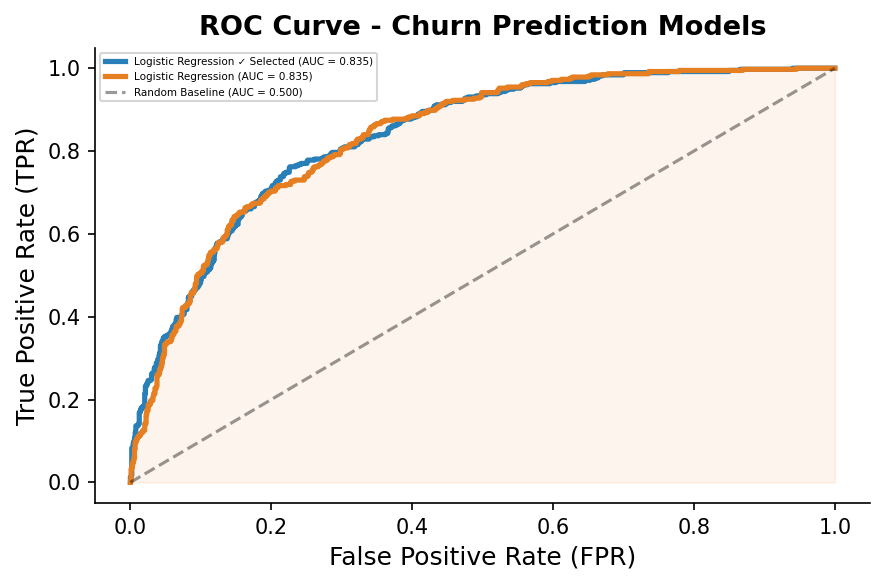

In [66]:
#ROC Curve

fpr_rf, tpr_rf, _ = roc_curve(Y_test, rf_probs)
fpr_lr, tpr_lr, _ = roc_curve(Y_test, lr_probs)

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(fpr_rf, tpr_rf, label=f'Logistic Regression ✓ Selected (AUC = {lr_auc:.3f})', color='#2980b9', linewidth=2.5)
ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_auc:.3f})', color='#e67e22', linewidth=2.5)
ax.plot([0,1], [0,1], 'k--', alpha=0.4, label='Random Baseline (AUC = 0.500)')
ax.fill_between(fpr_lr, tpr_lr, color='#e67e22', alpha=0.08)
ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR)')
ax.set_title('ROC Curve - Churn Prediction Models')
ax.legend(fontsize=5)

plt.tight_layout()
plt.savefig('charts/chart_roc_curve.png', bbox_inches='tight')
plt.show()

## 📊 Feature Importance — What Actually Drives Churn?

The Random Forest model tells us which features have the most predictive
power. This is more actionable than correlation — it reflects the actual
decision boundaries the model learned from 5,600+ training records.

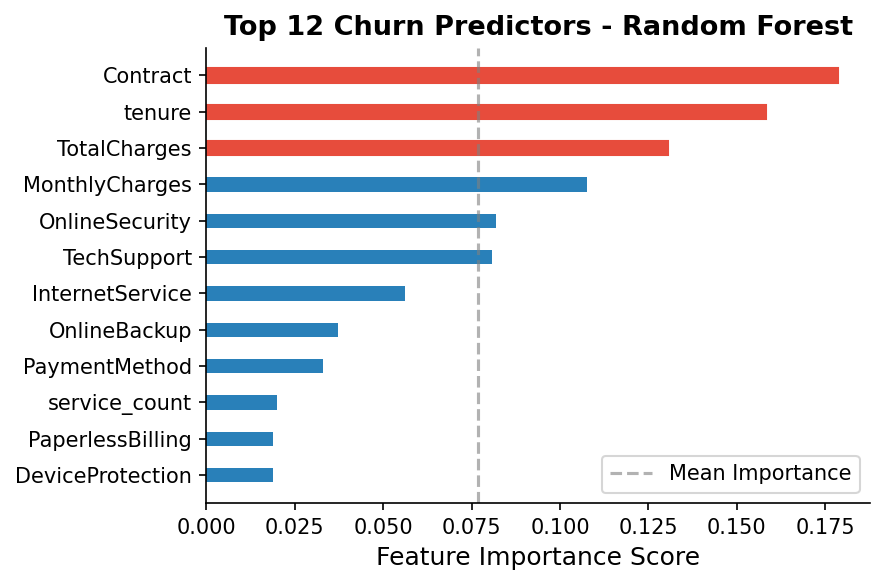

In [67]:
#Feature Importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance').tail(12)

fig, ax = plt.subplots(figsize=(6,4))
bars = ax.barh(importance_df['feature'], importance_df['importance'], color='#2980b9', height=0.4)

#Highlight Top 3
for i, bar in enumerate(bars):
  if i>=len(bars)-3:
    bar.set_color('#e74c3c')

ax.set_xlabel('Feature Importance Score')
ax.set_title('Top 12 Churn Predictors - Random Forest')
ax.axvline(importance_df['importance'].mean(), color='grey', linestyle='--', alpha=0.6, label='Mean Importance')
ax.legend()

plt.tight_layout()
plt.savefig('charts/chart_feature_importance.png', bbox_inches='tight')
plt.show()

## 💰 Customer Lifetime Value (CLV) Scoring

Churn probability alone doesn't tell us who to save first. A customer
with 80% churn probability paying ₹20/month is less urgent than one
with 50% churn probability paying ₹100/month.

We combine churn probability with expected revenue to produce a
**Retention Priority Score** — a dollar-weighted risk metric that tells
the retention team exactly where to spend effort.

Formula:
CLV = MonthlyCharges × (1 - churn_probability) × 24  # 24-month horizon
Retention Priority Score = churn_probability × MonthlyCharges

In [69]:
#Add churn probability from best model
df_scored = df.copy()
df_scored['Churn_probability'] = lr.predict_proba(X)[:,1].round(3)

#CLV- expected revenue over 24-months horizon given survival probability
df_scored['Predicted_CLV'] = (df_scored['MonthlyCharges']*(1-df_scored['Churn_probability'])*24).round(0)

#Retention Priority Score- Revenue Weighted Churn Risk
#High score = High churn probability and high revenue = contact first
df_scored['Retention_Priority_Score'] = (df_scored['Churn_probability']*df_scored['MonthlyCharges']).round(2)

#Risk tier based on Retention Priority Score
low = df_scored['Retention_Priority_Score'].quantile(0.33)
high = df_scored['Retention_Priority_Score'].quantile(0.66)

df_scored['Risk_tier'] = pd.cut(
    df_scored['Retention_Priority_Score'],
    bins=[-1, low, high, float('inf')],
    labels=['Low Priority', 'Medium Priority', 'High Priority']
)

# Save scored dataset for Power BI
df_scored.to_csv(f'{PROJECT_PATH}/Data/telco_churn_scored.csv', index=False)

#Sanity check- Distribution
print('Risk Tier Distribution based on Retention Priority Score')
print(df_scored['Risk_tier'].value_counts().round())

print(f"\nAvg churn probability: {df_scored['Churn_probability'].mean():.3f}")
print(f"Actual churn rate:     {df['Churn_Flag'].mean():.3f}")

Risk Tier Distribution based on Retention Priority Score
Risk_tier
High Priority      2390
Low Priority       2321
Medium Priority    2321
Name: count, dtype: int64

Avg churn probability: 0.267
Actual churn rate:     0.266


**Model calibration check:** Average predicted churn probability (0.267)
matches actual churn rate (0.266) — confirming the model produces
well-calibrated probability scores suitable for CLV and priority scoring.

## 💡 From Scoring to Action — Making It Operationally Useful

The full scored dataset flags 2,390 customers as High Priority —
too many for a retention team to action individually.

Two operational outputs narrow this to actionable scale:

1. **Top 50 contact list** — ranked by retention_priority_score,
   these are the highest revenue-weighted churn risks. A retention
   team of 5 can contact 10 customers each per week.

2. **Tier-based campaigns** — High Priority gets personal outreach,
   Medium Priority gets automated email sequences, Low Priority
   gets passive monitoring only.

This transforms a prediction model into an operational retention system.

Top 10 Customers- Contact Immediately
customerID  MonthlyCharges  Churn_probability  Predicted_CLV  Retention_Priority_Score       Contract  tenure     Risk_tier
1400-MMYXY          105.90              0.811          480.0                     85.88 Month-to-month       3 High Priority
7216-EWTRS          100.80              0.849          365.0                     85.58 Month-to-month       1 High Priority
6496-SLWHQ          105.00              0.805          491.0                     84.52 Month-to-month       3 High Priority
8884-ADFVN          101.95              0.827          423.0                     84.31 Month-to-month       7 High Priority
3389-YGYAI          105.50              0.791          529.0                     83.45 Month-to-month       8 High Priority
5419-JPRRN          101.45              0.819          441.0                     83.09 Month-to-month       1 High Priority
3606-TWKGI          106.90              0.771          588.0                     82.42 Month-t

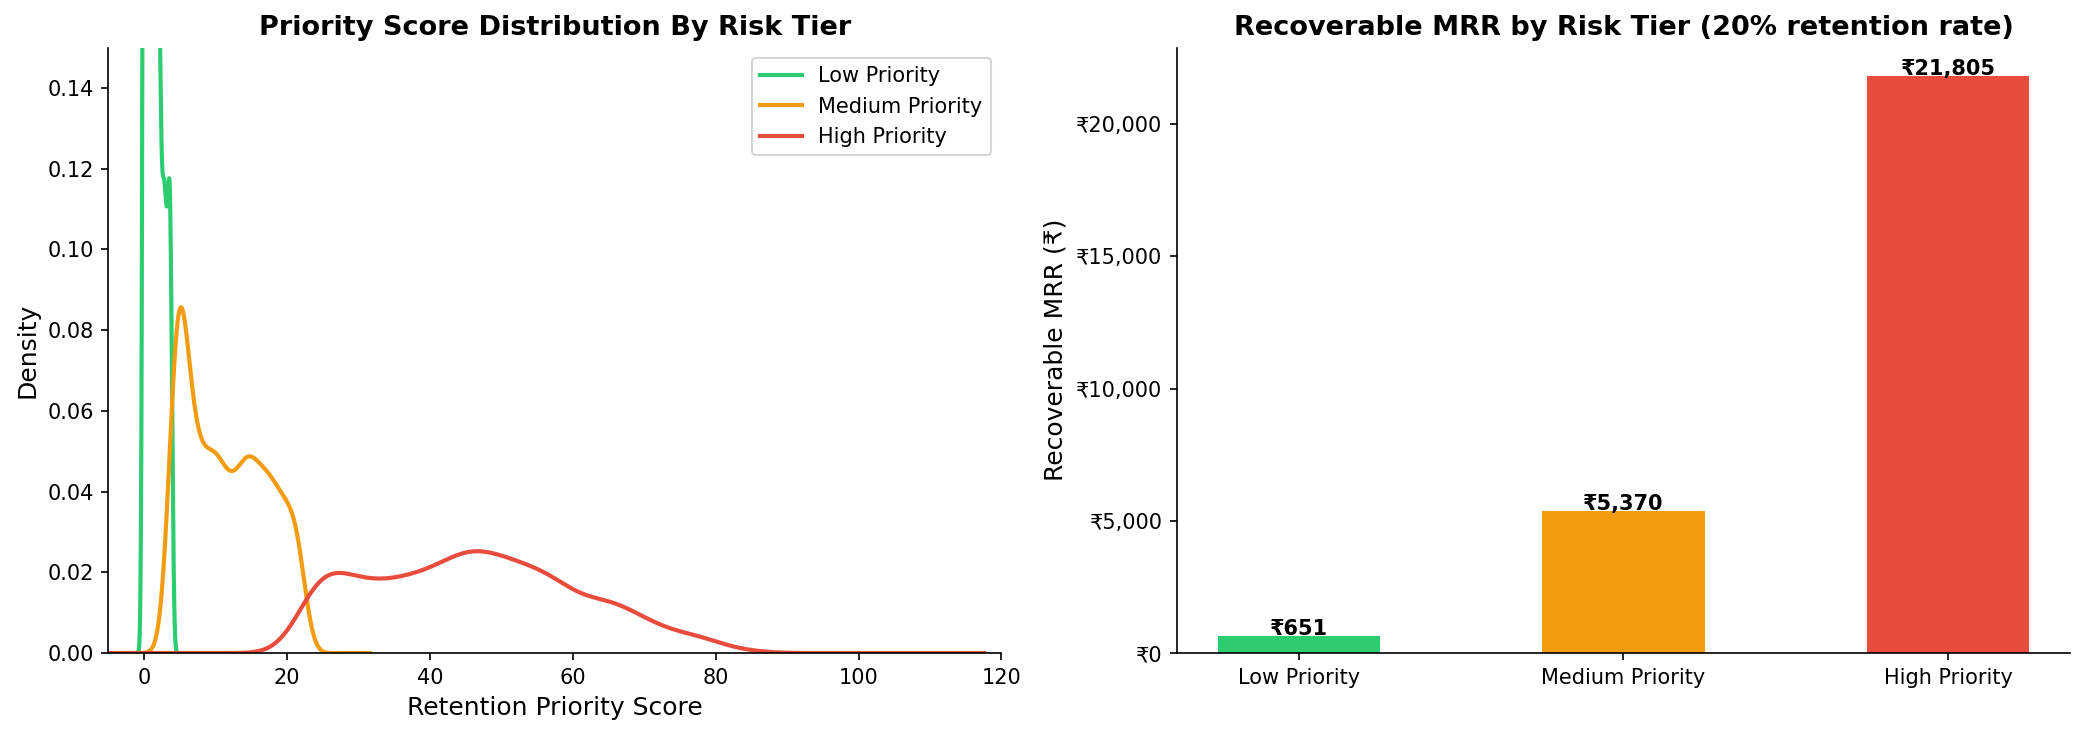

In [70]:
#Top 50 customers to contact first
Top_50 = df_scored[df_scored['Churn_Flag']==1].nlargest(50, 'Retention_Priority_Score')[['customerID','MonthlyCharges','Churn_probability','Predicted_CLV','Retention_Priority_Score','Contract','tenure','Risk_tier']]
Top_50.to_csv(f'{PROJECT_PATH}/Data/top50_priority_contacts.csv', index=False)

print('Top 10 Customers- Contact Immediately')
print('='*125)
print(Top_50.head(10).to_string(index=False))

#Revenue recoverable by tier
print("\n Revenue Recovery Potential by Risk Tier")
print("="*125)

#Assuming 20% of flagged customers are saved
recovery_rate = 0.2
tier_summary = df_scored.groupby('Risk_tier', observed=True).agg(
    total_customers=('customerID', 'count'),
    avg_churn_prob=('Churn_probability', 'mean'),
    total_monthly_rev_at_risk=('Revenue_at_risk', 'sum'),
    avg_priority_score=('Retention_Priority_Score','mean'),
    total_CLV=('Predicted_CLV','sum')
).reset_index()

tier_summary['Recoverable_MRR'] = (tier_summary['total_monthly_rev_at_risk']*recovery_rate).round(0)

print(tier_summary.to_string(index=False))

total_recoverable = tier_summary['Recoverable_MRR'].sum()
print(f"\nTotal recoverable MRR at 20% recovery rate: ₹{total_recoverable:,.0f}/month")
print(f"Annualised: ₹{(total_recoverable*12):,.0f}/year")

#Priority Score Distribution- Visual
fig,axes = plt.subplots(1,2, figsize=(14,5))

#Left- Score distribution by risk tier
for tier, color in zip(['Low Priority','Medium Priority','High Priority'], ['#2ecc71', '#f39c12', '#e74c3c']):
  subset = df_scored[df_scored['Risk_tier']==tier]['Retention_Priority_Score']
  subset.plot.kde(ax=axes[0], label=tier, color=color, linewidth=2)

axes[0].set_xlabel('Retention Priority Score')
axes[0].set_title('Priority Score Distribution By Risk Tier')
axes[0].legend()

#Right- Recoverable MRR by risk tier
colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[1].bar(tier_summary['Risk_tier'], tier_summary['Recoverable_MRR'], color=colors, width=0.5)
axes[1].set_title('Recoverable MRR by Risk Tier (20% retention rate)')
axes[1].set_ylabel('Recoverable MRR (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

for i,v in enumerate(tier_summary['Recoverable_MRR']):
  axes[1].text(i, v+50, f'₹{v:,.0f}', ha='center', fontweight='bold')

axes[0].set_xlim(-5, 120)  # focus on meaningful score range
axes[0].set_ylim(0, 0.15)  # prevent low priority spike dominating

plt.tight_layout()
plt.savefig('charts/chart_priority_tiers.png', bbox_inches='tight')
plt.show()

## 🎯 Final Business Recommendations

Based on SQL analysis of 7,032 customers and a Logistic Regression
model (AUC = 0.835, Churn Recall = 0.57), three interventions offer
the highest ROI:

---

**1. Immediate: Contact top 50 High Priority customers**
- All Month-to-month, MonthlyCharges > ₹100, churn probability > 0.80
- Combined retention_priority_score identifies these as highest
  revenue-weighted risks
- Retaining even 20% = ₹1,000+/month from 50 targeted calls

---

**2. Segment campaign: Month-to-month → Annual contract upgrade**
- 1,470 customers in 0–6 month cohort retaining at only 46.7%
- Offer: 10% discount on first annual contract within month 1–6
- Target: convert 15% → saves ~220 customers → ₹12,100/month

---

**3. Payment method intervention: Electronic check → Auto-pay**
- Highest risk combo: Month-to-month + Fiber optic + Electronic check
  = 60.4% churn rate, ₹68,282/month at risk
- Offer: ₹5/month discount for switching to auto-pay
- Cost: ~₹6,500/month in discounts
- Revenue protected: ₹68,282 × 10% retention = ₹6,828/month
- Net positive from day one

---

**Combined recoverable MRR at 20% retention rate: ₹27,826/month**
**Annualised revenue impact: ₹3,33,912/year**